<a href="https://colab.research.google.com/github/vedasri2511/DL-Assignment/blob/main/DL_Assign.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


would like to change the noise, hidden layer learning rate, feature dropout for each layer,

**FULLY CONNECTED NEURAL NETWORK**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, Adagrad

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
pip install torch torchvision

**MLP**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False)

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(32*32*3, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = MLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(trainloader):.4f}")

model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

100%|██████████| 170M/170M [00:06<00:00, 25.9MB/s]


Epoch [1/10], Loss: 1.6329
Epoch [2/10], Loss: 1.4125
Epoch [3/10], Loss: 1.2965
Epoch [4/10], Loss: 1.2015
Epoch [5/10], Loss: 1.1173
Epoch [6/10], Loss: 1.0408
Epoch [7/10], Loss: 0.9674
Epoch [8/10], Loss: 0.8897
Epoch [9/10], Loss: 0.8108
Epoch [10/10], Loss: 0.7402
Test Accuracy: 54.05%


**ANN**

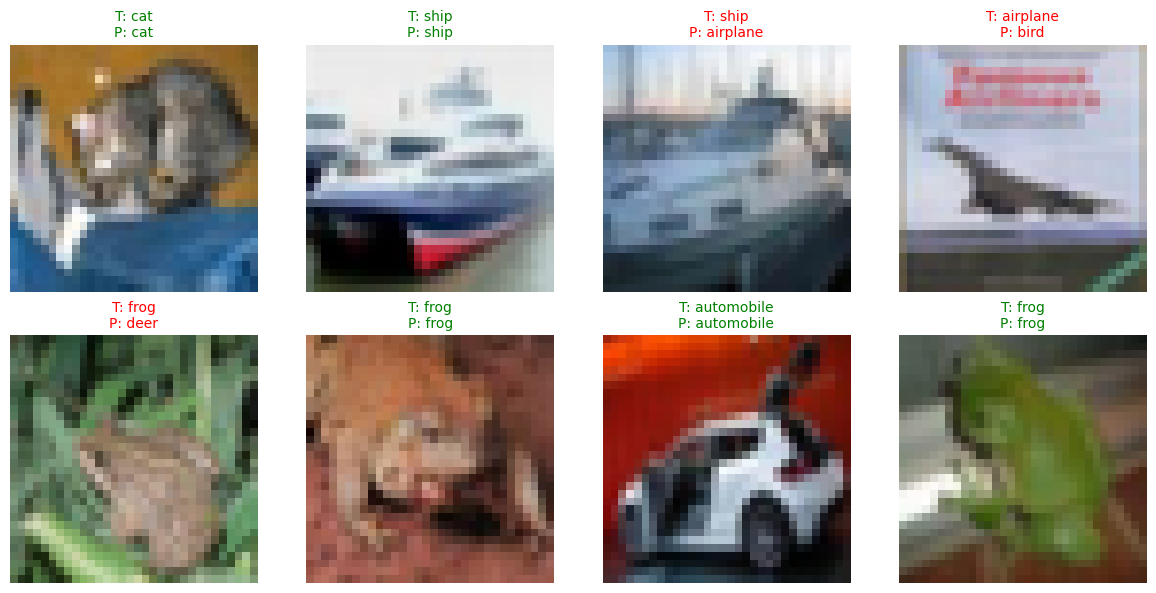

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

classes = ('airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck')

def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')

dataiter = iter(testloader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

outputs = model(images)
_, predicted = torch.max(outputs, 1)

plt.figure(figsize=(12,6))
for i in range(8):
    plt.subplot(2,4,i+1)
    imshow(images[i].cpu())
    color = "green" if predicted[i] == labels[i] else "red"
    plt.title(
        f"T: {classes[labels[i]]}\nP: {classes[predicted[i]]}",
        color=color,
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [ ]:
# show more samples to find some correct ANN predictions
for i in range(50):
    if ann_pred[i] == labels[i]:
        print("Correct at index:", i)

NameError: name 'ann_pred' is not defined

**CNN**

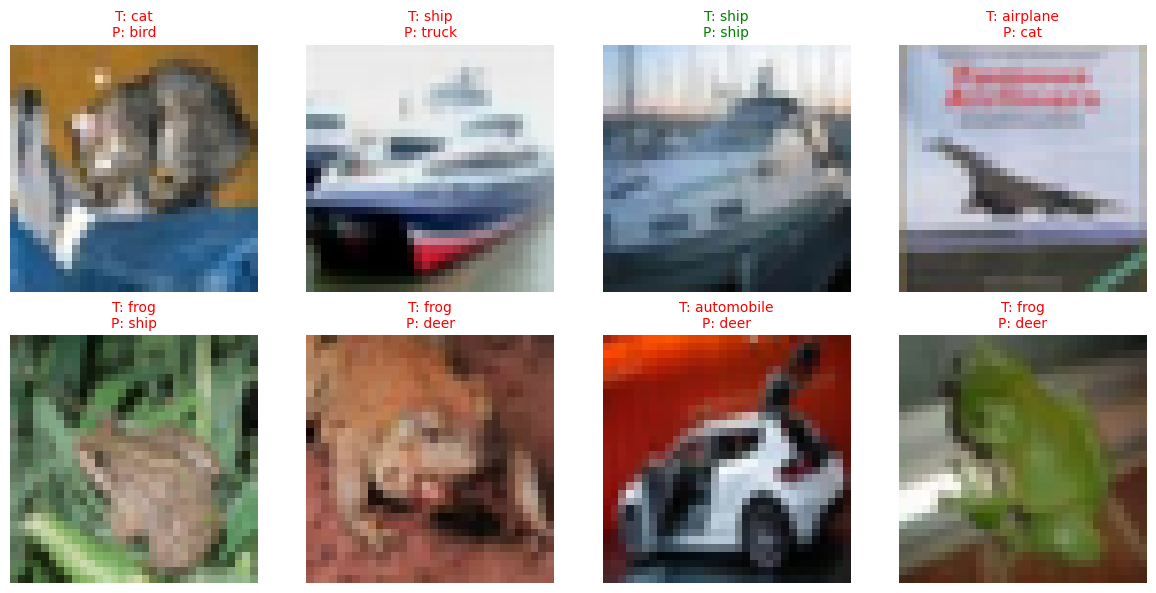

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

classes = ('airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck')

def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')

dataiter = iter(testloader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

cnn_model = SimpleCNN().to(device)
outputs = cnn_model(images)
_, predicted = torch.max(outputs, 1)

plt.figure(figsize=(12,6))
for i in range(8):
    plt.subplot(2,4,i+1)
    imshow(images[i].cpu())
    color = "green" if predicted[i] == labels[i] else "red"
    plt.title(f"T: {classes[labels[i]]}\nP: {classes[predicted[i]]}",
              color=color, fontsize=10)

plt.tight_layout()
plt.show()

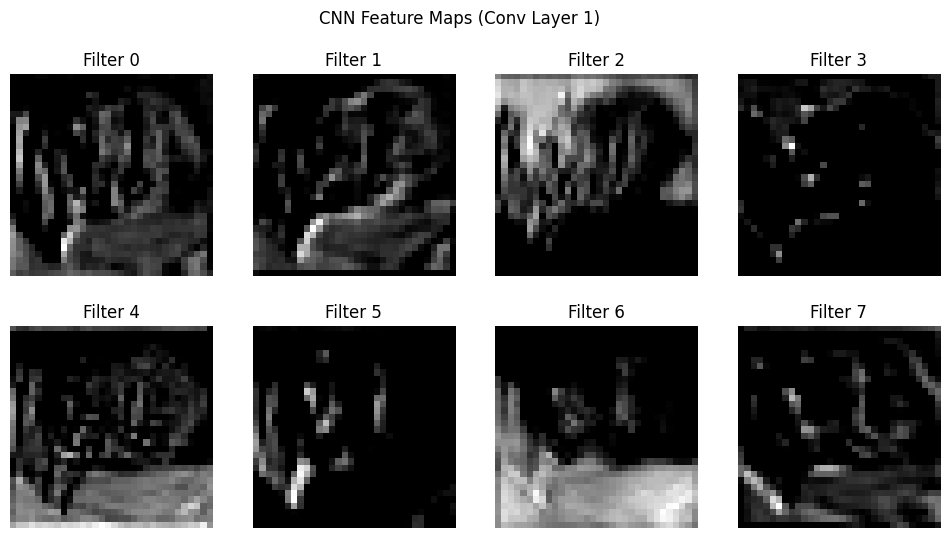

In [ ]:
with torch.no_grad():
    feature_maps = cnn_model.relu(cnn_model.conv1(images[0:1]))

plt.figure(figsize=(12,6))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(feature_maps[0,i].cpu(), cmap='gray')
    plt.axis('off')
    plt.title(f"Filter {i}")

plt.suptitle("CNN Feature Maps (Conv Layer 1)")
plt.show()

**OBSERVATION**

Edges


Corners

Texture patterns
→ Proof that CNN learns spatial features

**ANN VS CNN**

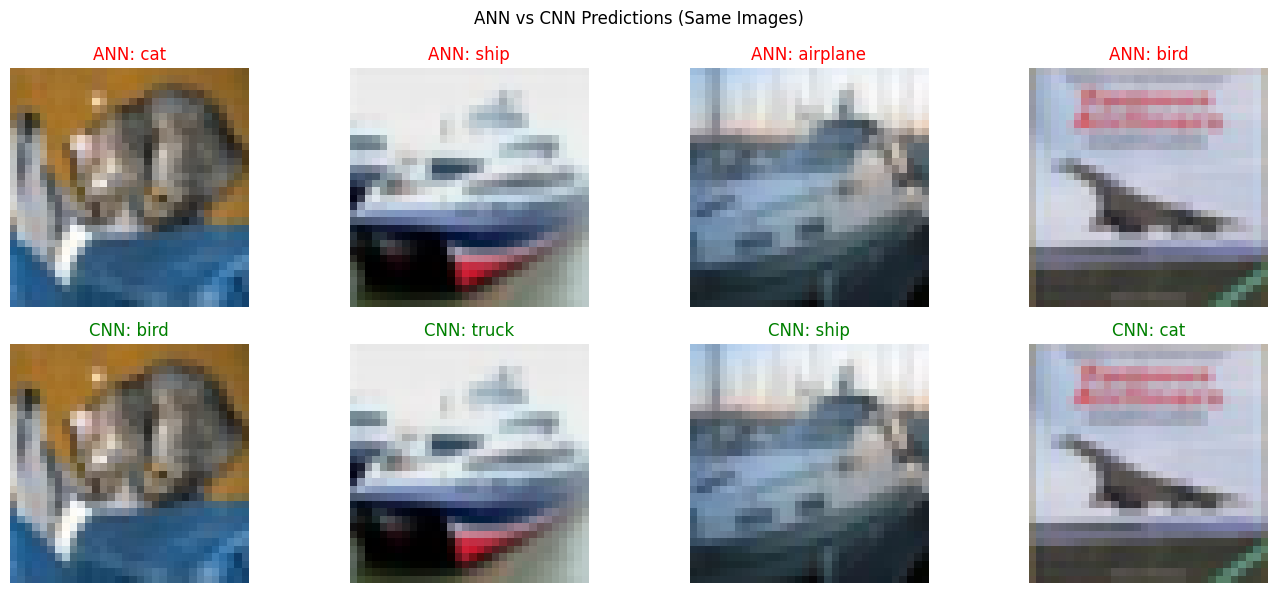

In [ ]:
ann_outputs = model(images)
_, ann_pred = torch.max(ann_outputs, 1)

cnn_outputs = cnn_model(images)
_, cnn_pred = torch.max(cnn_outputs, 1)

plt.figure(figsize=(14,6))

for i in range(4):
    plt.subplot(2,4,i+1)
    imshow(images[i].cpu())
    plt.title(f"ANN: {classes[ann_pred[i]]}", color='red')

    plt.subplot(2,4,i+5)
    imshow(images[i].cpu())
    plt.title(f"CNN: {classes[cnn_pred[i]]}", color='green')

plt.suptitle("ANN vs CNN Predictions (Same Images)")
plt.tight_layout()
plt.show()

actual

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False)

classes = ('airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck')

100%|██████████| 170M/170M [02:33<00:00, 1.11MB/s]


In [ ]:
#ann mlp model
class ANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(32*32*3, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(x.size(0), -1)   # FLATTEN IMAGE
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

ann_model = ANN().to(device)

In [ ]:
#cnn model
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(64*8*8, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

cnn_model = CNN().to(device)

In [ ]:
#training for both ann and cnn
def train_model(model, epochs=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss/len(trainloader):.4f}")

In [ ]:
print("Training ANN")
train_model(ann_model)

print("\nTraining CNN")
train_model(cnn_model)

Training ANN
Epoch 1, Loss: 1.6329
Epoch 2, Loss: 1.4110
Epoch 3, Loss: 1.2933
Epoch 4, Loss: 1.1973
Epoch 5, Loss: 1.1114

Training CNN
Epoch 1, Loss: 1.3938
Epoch 2, Loss: 0.9967
Epoch 3, Loss: 0.8393
Epoch 4, Loss: 0.7204
Epoch 5, Loss: 0.6188


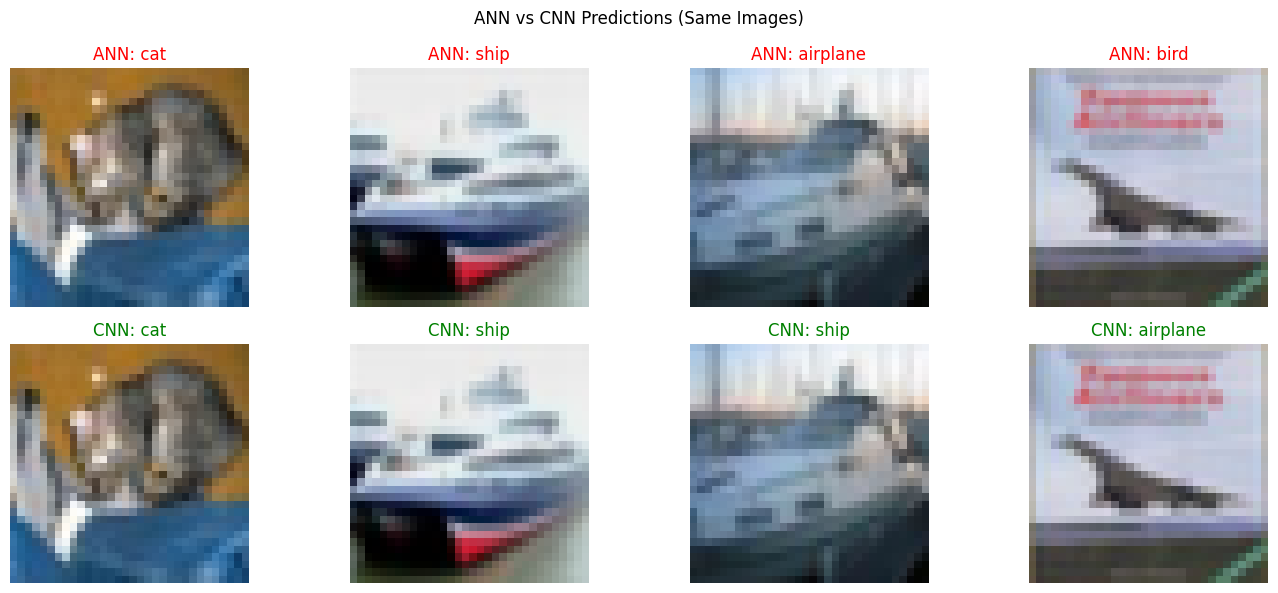

In [ ]:
def imshow(img):
    img = img / 2 + 0.5
    npimg = img.cpu().numpy()
    plt.imshow(np.transpose(npimg, (1,2,0)))
    plt.axis('off')

dataiter = iter(testloader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

ann_out = ann_model(images)
cnn_out = cnn_model(images)

_, ann_pred = torch.max(ann_out, 1)
_, cnn_pred = torch.max(cnn_out, 1)

plt.figure(figsize=(14,6))

for i in range(4):
    plt.subplot(2,4,i+1)
    imshow(images[i])
    plt.title(f"ANN: {classes[ann_pred[i]]}", color='red')

    plt.subplot(2,4,i+5)
    imshow(images[i])
    plt.title(f"CNN: {classes[cnn_pred[i]]}", color='green')

plt.suptitle("ANN vs CNN Predictions (Same Images)")
plt.tight_layout()
plt.show()

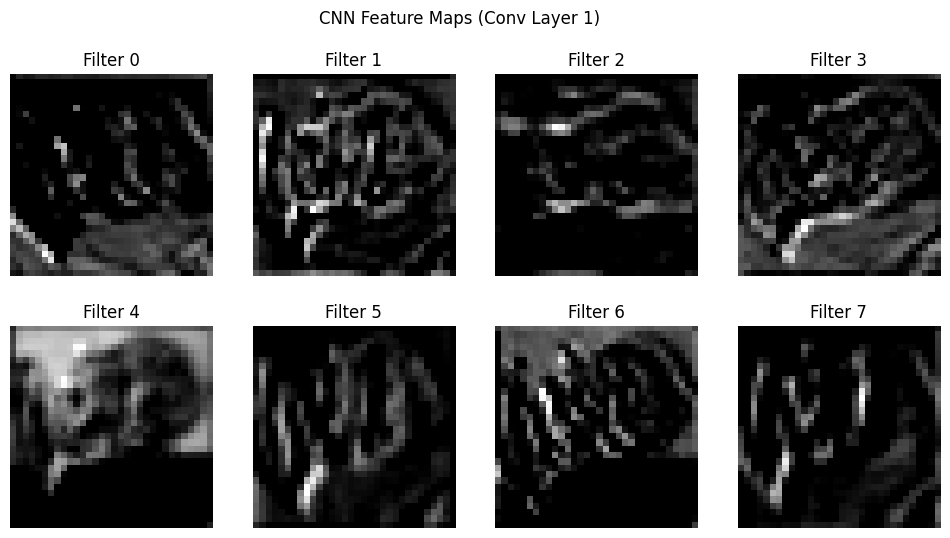

In [ ]:
with torch.no_grad():
    feature_maps = cnn_model.relu(cnn_model.conv1(images[0:1]))

plt.figure(figsize=(12,6))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(feature_maps[0,i].cpu(), cmap='gray')
    plt.axis('off')
    plt.title(f"Filter {i}")

plt.suptitle("CNN Feature Maps (Conv Layer 1)")
plt.show()

Filter

In [ ]:
pip install torch torchvision opencv-python matplotlib

loading the dataset

In [ ]:
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import cv2

transform = transforms.ToTensor()

dataset = torchvision.datasets.CIFAR10(root='./data', download=True, transform=transform)
image, label = dataset[0]

img = image.permute(1,2,0).numpy()

100%|██████████| 170M/170M [00:15<00:00, 11.2MB/s]


apply filters

In [ ]:
# Convert to uint8
img_uint8 = (img * 255).astype(np.uint8)

# 1. Gaussian Blur
gaussian = cv2.GaussianBlur(img_uint8, (5,5), 0)

# 2. Median Filter
median = cv2.medianBlur(img_uint8, 5)

# 3. Sobel Edge Detection
sobel = cv2.Sobel(img_uint8, cv2.CV_64F, 1, 1, ksize=5)

# 4. Laplacian (Sharpen)
laplacian = cv2.Laplacian(img_uint8, cv2.CV_64F)

# 5. Add Noise
noise = img_uint8 + np.random.normal(0,25,img_uint8.shape)
noise = np.clip(noise,0,255).astype(np.uint8)

display the results

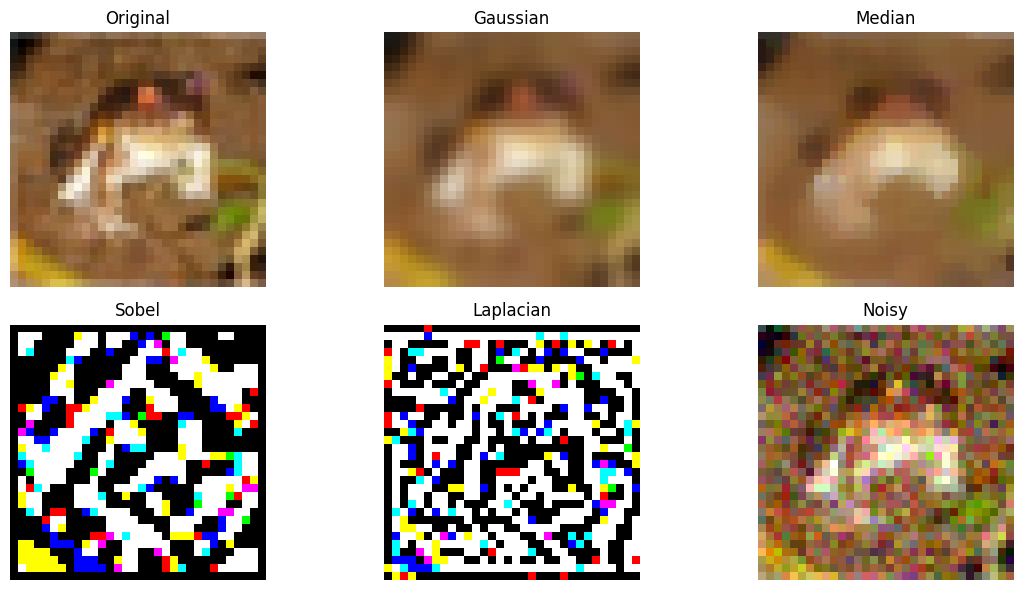

In [ ]:
titles = ['Original','Gaussian','Median','Sobel','Laplacian','Noisy']
images = [img_uint8, gaussian, median, sobel, laplacian, noise]

plt.figure(figsize=(12,6))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

applying filters with padding

1. load the image

In [ ]:
import torchvision
import matplotlib.pyplot as plt
import numpy as np
import cv2

dataset = torchvision.datasets.CIFAR10(root='./data', download=True)
img, _ = dataset[0]

img = np.array(img)

Step 2: Apply Different Padding Types

In [ ]:
# Zero Padding
zero_pad = cv2.copyMakeBorder(img, 20,20,20,20, cv2.BORDER_CONSTANT, value=0)

# Reflect Padding
reflect_pad = cv2.copyMakeBorder(img, 20,20,20,20, cv2.BORDER_REFLECT)

# Replicate Padding
replicate_pad = cv2.copyMakeBorder(img, 20,20,20,20, cv2.BORDER_REPLICATE)

Step 3: Apply Gaussian Filter on Each

In [ ]:
gauss_zero = cv2.GaussianBlur(zero_pad, (5,5), 0)
gauss_reflect = cv2.GaussianBlur(reflect_pad, (5,5), 0)
gauss_replicate = cv2.GaussianBlur(replicate_pad, (5,5), 0)

Step 4: Display Results

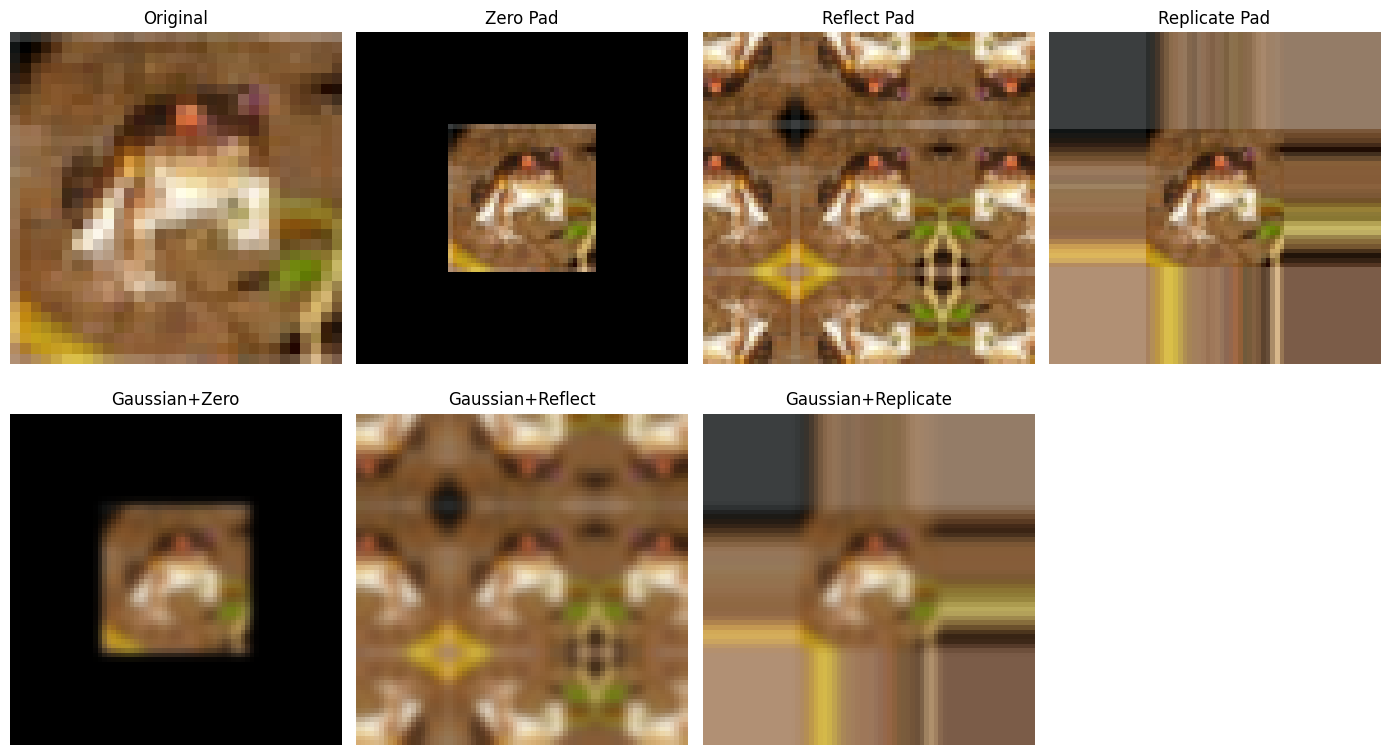

In [ ]:
titles = ['Original','Zero Pad','Reflect Pad','Replicate Pad',
          'Gaussian+Zero','Gaussian+Reflect','Gaussian+Replicate']

images = [img, zero_pad, reflect_pad, replicate_pad,
          gauss_zero, gauss_reflect, gauss_replicate]

plt.figure(figsize=(14,8))

for i in range(len(images)):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

rotating the filters

Step 1: Load Image

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torchvision

dataset = torchvision.datasets.CIFAR10(root='./data', download=True)
img, _ = dataset[0]
img = np.array(img)

gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

Step 2: Define Base Filter (Edge Detector)

In [ ]:
# Horizontal edge detector (Sobel-like)
kernel = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
])

Step 3: Rotate Filter

In [ ]:
kernel_90 = np.rot90(kernel)
kernel_180 = np.rot90(kernel, 2)
kernel_270 = np.rot90(kernel, 3)

Step 4: Apply Convolution

In [ ]:
out_0 = cv2.filter2D(gray, -1, kernel)
out_90 = cv2.filter2D(gray, -1, kernel_90)
out_180 = cv2.filter2D(gray, -1, kernel_180)
out_270 = cv2.filter2D(gray, -1, kernel_270)

Step 5: Display Results

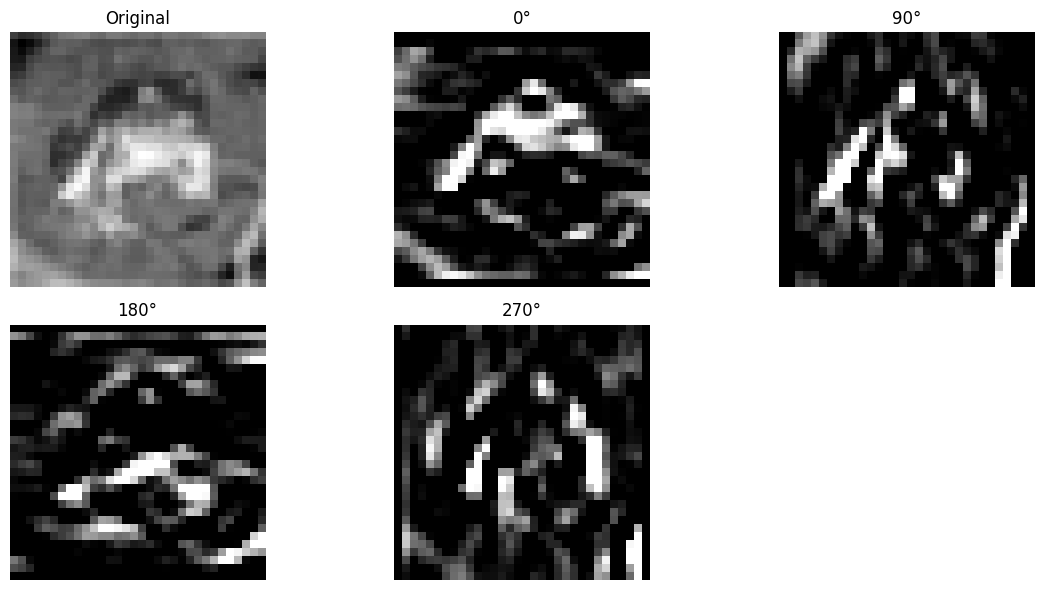

In [ ]:
titles = ['Original','0°','90°','180°','270°']
images = [gray, out_0, out_90, out_180, out_270]

plt.figure(figsize=(12,6))

for i in range(5):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

* 0° Filter


Detects horizontal edges
* 90° Rotation
Detects vertical edges
* 180°
Same edges but reversed intensity
* 270°
Detects edges in opposite orientation



filter slicing

full code

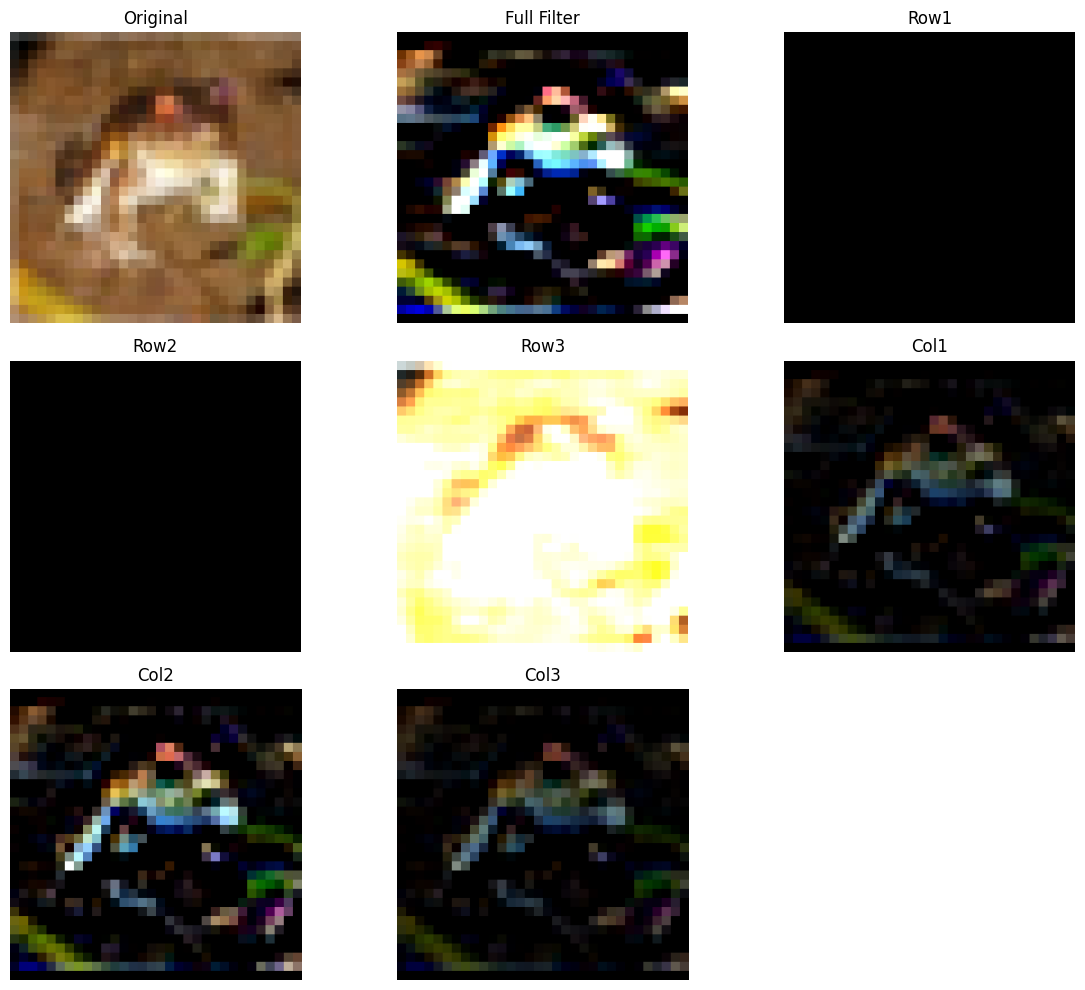

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torchvision

# Load CIFAR-10 image
dataset = torchvision.datasets.CIFAR10(root='./data', download=True)
img, _ = dataset[0]
img = np.array(img)

#  STEP 1: Resize for clarity
img_resized = cv2.resize(img, (256,256), interpolation=cv2.INTER_NEAREST)

#  STEP 2: Define filter
kernel = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
])

#  STEP 3: Slice filters
row1 = np.array([kernel[0]])
row2 = np.array([kernel[1]])
row3 = np.array([kernel[2]])

col1 = kernel[:,0].reshape(3,1)
col2 = kernel[:,1].reshape(3,1)
col3 = kernel[:,2].reshape(3,1)

#  STEP 4: Apply filter to COLOR image
def apply_filter_color(image, kernel):
    channels = cv2.split(image)
    filtered_channels = [cv2.filter2D(ch, -1, kernel) for ch in channels]
    return cv2.merge(filtered_channels)

full_out = apply_filter_color(img, kernel)

r1_out = apply_filter_color(img, row1)
r2_out = apply_filter_color(img, row2)
r3_out = apply_filter_color(img, row3)

c1_out = apply_filter_color(img, col1)
c2_out = apply_filter_color(img, col2)
c3_out = apply_filter_color(img, col3)

#  STEP 5: Resize outputs
def resize(image):
    return cv2.resize(image, (256,256), interpolation=cv2.INTER_NEAREST)

#  STEP 6: Display results
titles = ['Original','Full Filter',
          'Row1','Row2','Row3',
          'Col1','Col2','Col3']

images = [
    img_resized,
    resize(full_out),
    resize(r1_out),
    resize(r2_out),
    resize(r3_out),
    resize(c1_out),
    resize(c2_out),
    resize(c3_out)
]

plt.figure(figsize=(12,10))

for i in range(len(images)):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

reference point (to get a clear image)

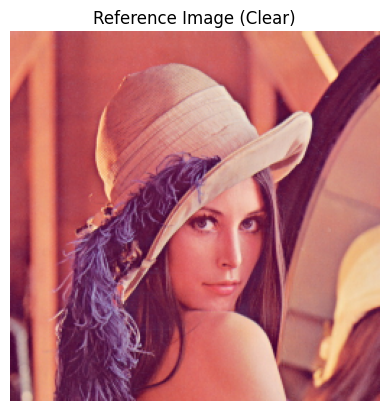

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

# Image URL (you can change this)
# Changed to a more accessible URL
url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"

# Read image from URL
try:
    resp = urllib.request.urlopen(url)
    image = np.asarray(bytearray(resp.read()), dtype="uint8")
    img = cv2.imdecode(image, cv2.IMREAD_COLOR)

    # Check if image decoding was successful
    if img is None:
        raise ValueError("Could not decode image from URL.")

    # Convert to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize for display
    img = cv2.resize(img, (256,256))

    plt.imshow(img)
    plt.title("Reference Image (Clear)")
    plt.axis('off')
    plt.show()
except urllib.error.HTTPError as e:
    print(f"HTTP Error: {e.code} - {e.reason}. Please check the URL or try a different one.")
    print("Could not load image from URL. Displaying a blank image.")
    # Display a blank image as a fallback
    plt.imshow(np.zeros((256, 256, 3), dtype=np.uint8))
    plt.title("Image Not Loaded")
    plt.axis('off')
    plt.show()
except Exception as e:
    print(f"An error occurred: {e}")
    print("Could not load image from URL. Displaying a blank image.")
    # Display a blank image as a fallback
    plt.imshow(np.zeros((256, 256, 3), dtype=np.uint8))
    plt.title("Image Not Loaded")
    plt.axis('off')
    plt.show()

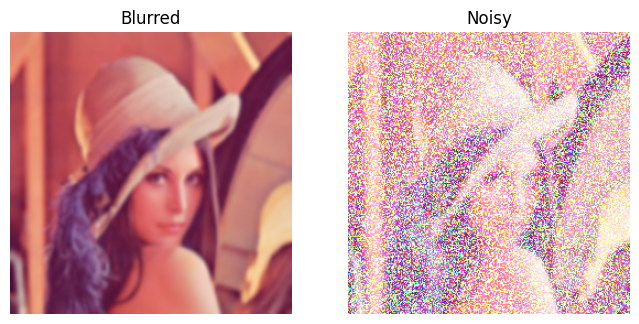

In [ ]:
# Add blur
blurred = cv2.GaussianBlur(img, (9,9), 0)

# Add noise
noise = np.random.normal(0,25,img.shape).astype(np.uint8)
noisy = cv2.add(blurred, noise)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(blurred)
plt.title("Blurred")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(noisy)
plt.title("Noisy")
plt.axis('off')

plt.show()

In [ ]:
# Convert to float
guide = img.astype(np.float32) / 255.0
target = noisy.astype(np.float32) / 255.0

radius = 5
eps = 1e-3

mean_I = cv2.boxFilter(guide, -1, (radius,radius))
mean_p = cv2.boxFilter(target, -1, (radius,radius))
mean_Ip = cv2.boxFilter(guide * target, -1, (radius,radius))

cov_Ip = mean_Ip - mean_I * mean_p

mean_II = cv2.boxFilter(guide * guide, -1, (radius,radius))
var_I = mean_II - mean_I * mean_I

a = cov_Ip / (var_I + eps)
b = mean_p - a * mean_I

mean_a = cv2.boxFilter(a, -1, (radius,radius))
mean_b = cv2.boxFilter(b, -1, (radius,radius))

output = mean_a * guide + mean_b

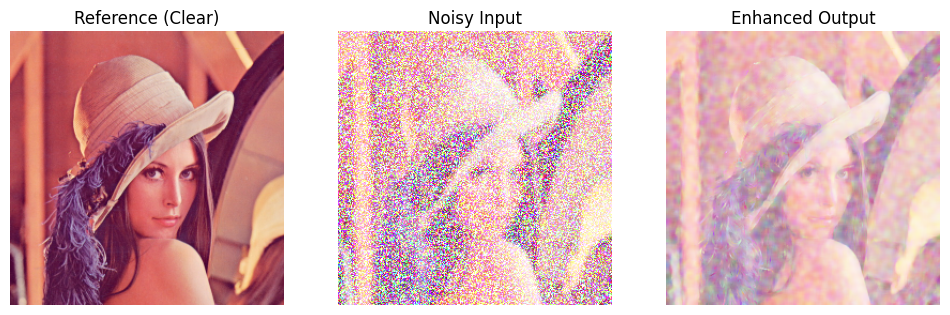

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Reference (Clear)")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(noisy)
plt.title("Noisy Input")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(output)
plt.title("Enhanced Output")
plt.axis('off')

plt.show()

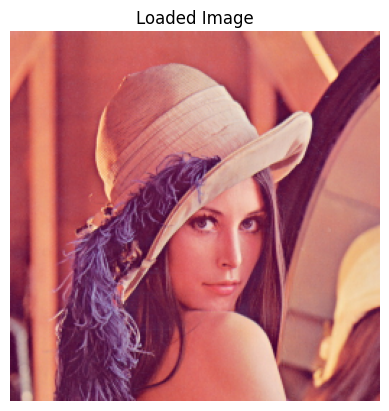

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg" # Changed to a publicly accessible URL

try:
    resp = urllib.request.urlopen(url)
    image = np.asarray(bytearray(resp.read()), dtype="uint8")
    img = cv2.imdecode(image, cv2.IMREAD_COLOR)

    if img is None:
        raise ValueError("Could not decode image from URL.")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (256,256))

    plt.imshow(img)
    plt.title("Loaded Image")
    plt.axis('off')
    plt.show()
except urllib.error.HTTPError as e:
    print(f"HTTP Error: {e.code} - {e.reason}. Please check the URL or try a different one.")
    print("Could not load image from URL. Displaying a blank image.")
    plt.imshow(np.zeros((256, 256, 3), dtype=np.uint8))
    plt.title("Image Not Loaded")
    plt.axis('off')
    plt.show()
except Exception as e:
    print(f"An error occurred: {e}")
    print("Could not load image from URL. Displaying a blank image.")
    plt.imshow(np.zeros((256, 256, 3), dtype=np.uint8))
    plt.title("Image Not Loaded")
    plt.axis('off')
    plt.show()

In [ ]:
blurred = cv2.GaussianBlur(img, (9,9), 0)

noise = np.random.normal(0,25,img.shape).astype(np.uint8)
noisy = cv2.add(blurred, noise)

In [ ]:
#iterated guided filtring
guide = img.astype(np.float32) / 255.0
current = noisy.astype(np.float32) / 255.0

radius = 5
eps = 1e-3

results = [current.copy()]

for i in range(6):  # number of iterations

    mean_I = cv2.boxFilter(guide, -1, (radius,radius))
    mean_p = cv2.boxFilter(current, -1, (radius,radius))
    mean_Ip = cv2.boxFilter(guide * current, -1, (radius,radius))

    cov_Ip = mean_Ip - mean_I * mean_p

    mean_II = cv2.boxFilter(guide * guide, -1, (radius,radius))
    var_I = mean_II - mean_I * mean_I

    a = cov_Ip / (var_I + eps)
    b = mean_p - a * mean_I

    mean_a = cv2.boxFilter(a, -1, (radius,radius))
    mean_b = cv2.boxFilter(b, -1, (radius,radius))

    current = mean_a * guide + mean_b

    results.append(current.copy())

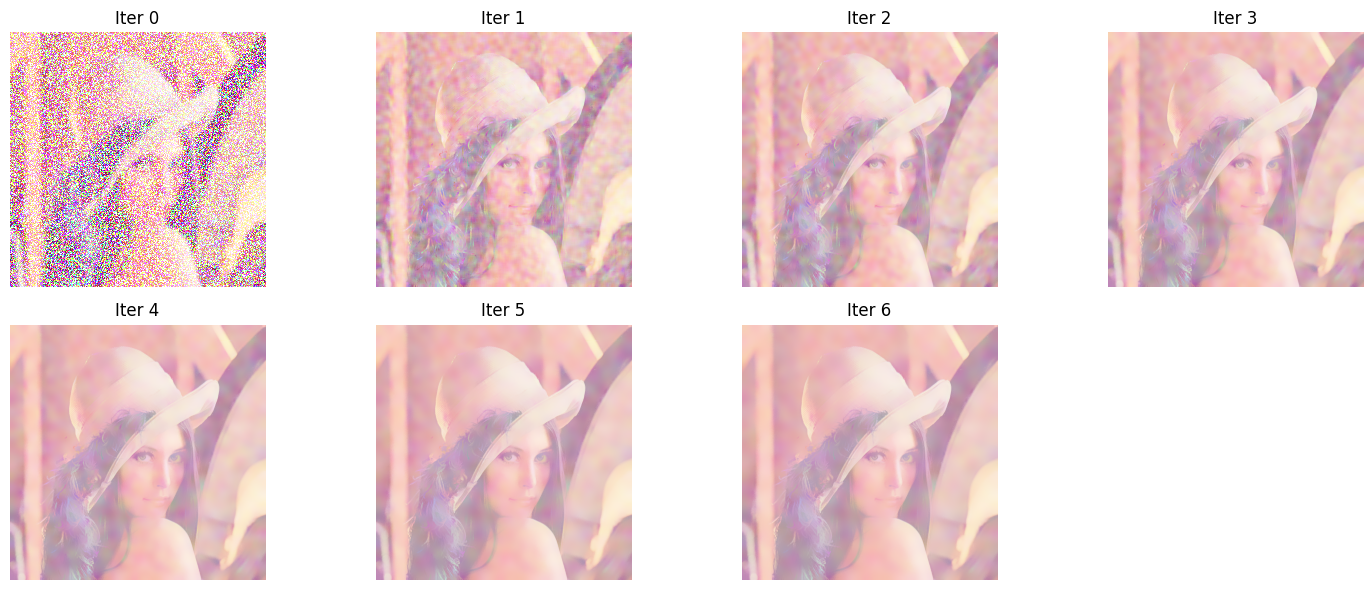

In [ ]:
plt.figure(figsize=(15,6))

for i in range(len(results)):
    plt.subplot(2,4,i+1)
    plt.imshow(results[i])
    plt.title(f"Iter {i}")
    plt.axis('off')

plt.tight_layout()
plt.show()

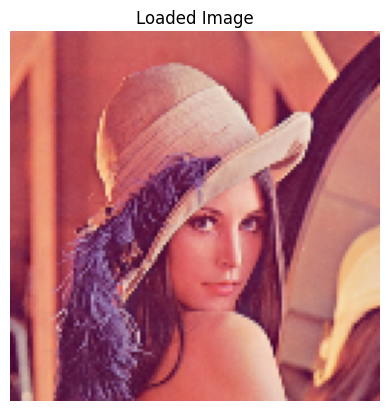

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

# Using a publicly accessible URL for demonstration
url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"

try:
    resp = urllib.request.urlopen(url)
    image = np.asarray(bytearray(resp.read()), dtype="uint8")
    img = cv2.imdecode(image, cv2.IMREAD_COLOR)

    if img is None:
        raise ValueError("Could not decode image from URL.")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (128,128))

    plt.imshow(img)
    plt.title("Loaded Image")
    plt.axis('off')
    plt.show()
except urllib.error.HTTPError as e:
    print(f"HTTP Error: {e.code} - {e.reason}. Please check the URL or try a different one.")
    print("Could not load image from URL. Displaying a blank image.")
    plt.imshow(np.zeros((128, 128, 3), dtype=np.uint8))
    plt.title("Image Not Loaded")
    plt.axis('off')
    plt.show()
except Exception as e:
    print(f"An error occurred: {e}")
    print("Could not load image from URL. Displaying a blank image.")
    plt.imshow(np.zeros((128, 128, 3), dtype=np.uint8))
    plt.title("Image Not Loaded")
    plt.axis('off')
    plt.show()